In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")


In [4]:
transactions.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
customers.head()


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [6]:
transactions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [7]:
customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [8]:
transactions.shape

(264836, 8)

In [9]:
customers.shape

(72637, 3)

In [10]:
transactions["DATE"] = pd.to_datetime(
    transactions["DATE"], unit="D", origin="1899-12-30"
)


In [12]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [13]:
transactions["PROD_NAME"].head(20)


,PROD_NAME
0,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g
5,Old El Paso Salsa Dip Tomato Mild 300g
6,Smiths Crinkle Chips Salt & Vinegar 330g
7,Grain Waves Sweet Chilli 210g
8,Doritos Corn Chip Mexican Jalapeno 150g
9,Grain Waves Sour Cream&Chives 210G


In [14]:
transactions["PROD_NAME"].str.contains("salsa", case=False).sum()


np.int64(18094)

In [15]:
transactions = transactions[~transactions["PROD_NAME"].str.contains("salsa", case=False)]


In [16]:
transactions["PROD_NAME"].str.contains("salsa", case=False).sum()


np.int64(0)

In [17]:
transactions["PROD_QTY"].describe()


,PROD_QTY
count,246742.000000
mean,1.908062
std,0.659831
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,200.000000


In [18]:
transactions[transactions["PROD_QTY"] > 50]


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [19]:
transactions = transactions[transactions["LYLTY_CARD_NBR"] != 226000]


In [20]:
transactions["PROD_QTY"].describe()


,PROD_QTY
count,246740.000000
mean,1.906456
std,0.342499
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,5.000000


In [21]:
transactions_per_day = transactions.groupby("DATE").size()

transactions_per_day.head()


,0
DATE,
2018-07-01,663
2018-07-02,650
2018-07-03,674
2018-07-04,669
2018-07-05,660


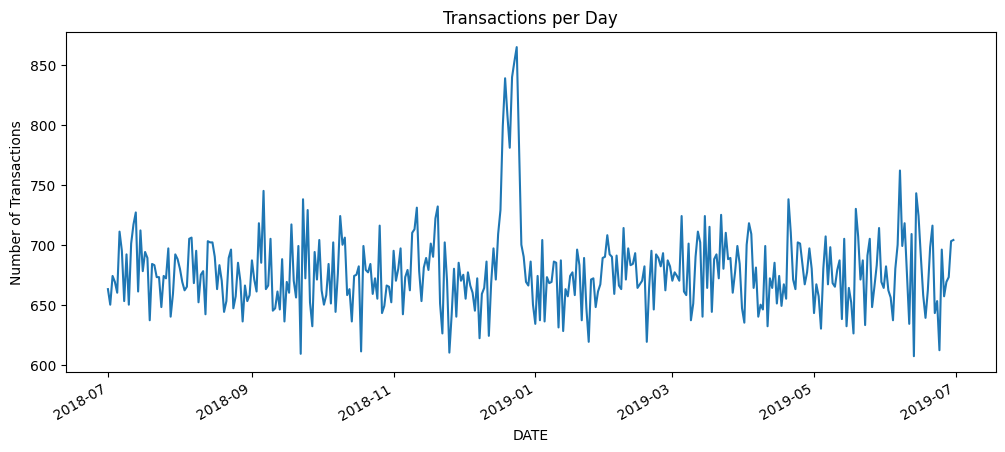

In [22]:
import matplotlib.pyplot as plt

transactions_per_day.plot(figsize=(12,5))
plt.title("Transactions per Day")
plt.ylabel("Number of Transactions")
plt.show()


In [23]:
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract(r'(\d+)').astype(int)


In [24]:
transactions["PACK_SIZE"].describe()


,PACK_SIZE
count,246740.000000
mean,175.583521
std,59.432118
min,70.000000
25%,150.000000
50%,170.000000
75%,175.000000
max,380.000000


In [25]:
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0]


In [26]:
transactions["BRAND"].value_counts().head(10)


,count
BRAND,
Kettle,41288
Smiths,27390
Pringles,25102
Doritos,22041
Thins,14075
RRD,11894
Infuzions,11057
WW,10320
Cobs,9693


In [27]:
transactions["BRAND"] = transactions["BRAND"].replace({"RED": "RRD"})


In [28]:
data = transactions.merge(customers, on="LYLTY_CARD_NBR", how="left")


In [29]:
data.shape


(246740, 12)

In [30]:
data.isnull().sum()


,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


In [31]:
sales_by_segment = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
)["TOT_SALES"].sum().reset_index()

sales_by_segment


,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
0,MIDAGE SINGLES/COUPLES,Budget,33345.70
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25
2,MIDAGE SINGLES/COUPLES,Premium,54443.85
3,NEW FAMILIES,Budget,20607.45
4,NEW FAMILIES,Mainstream,15979.70
5,NEW FAMILIES,Premium,10760.80
6,OLDER FAMILIES,Budget,156863.75
7,OLDER FAMILIES,Mainstream,96413.55
8,OLDER FAMILIES,Premium,75242.60
9,OLDER SINGLES/COUPLES,Budget,127833.60


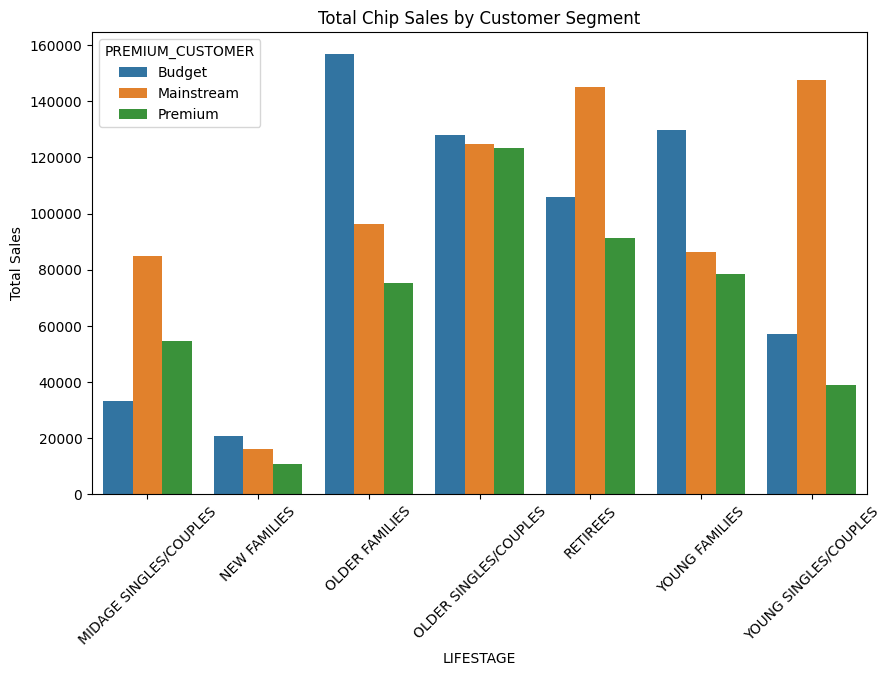

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=sales_by_segment,
    x="LIFESTAGE",
    y="TOT_SALES",
    hue="PREMIUM_CUSTOMER"
)

plt.xticks(rotation=45)
plt.title("Total Chip Sales by Customer Segment")
plt.ylabel("Total Sales")
plt.show()


In [33]:
customers_per_segment = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
)["LYLTY_CARD_NBR"].nunique().reset_index()

customers_per_segment


,LIFESTAGE,PREMIUM_CUSTOMER,LYLTY_CARD_NBR
0,MIDAGE SINGLES/COUPLES,Budget,1474
1,MIDAGE SINGLES/COUPLES,Mainstream,3298
2,MIDAGE SINGLES/COUPLES,Premium,2369
3,NEW FAMILIES,Budget,1087
4,NEW FAMILIES,Mainstream,830
5,NEW FAMILIES,Premium,575
6,OLDER FAMILIES,Budget,4611
7,OLDER FAMILIES,Mainstream,2788
8,OLDER FAMILIES,Premium,2231
9,OLDER SINGLES/COUPLES,Budget,4849


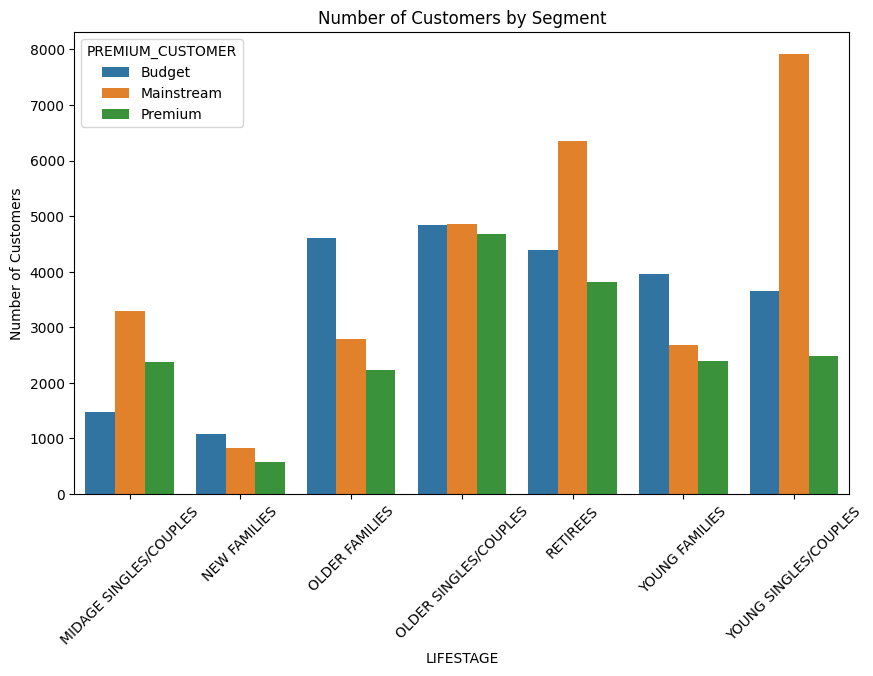

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=customers_per_segment,
    x="LIFESTAGE",
    y="LYLTY_CARD_NBR",
    hue="PREMIUM_CUSTOMER"
)

plt.xticks(rotation=45)
plt.title("Number of Customers by Segment")
plt.ylabel("Number of Customers")
plt.show()


In [35]:
units_per_customer = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
)["PROD_QTY"].mean().reset_index()


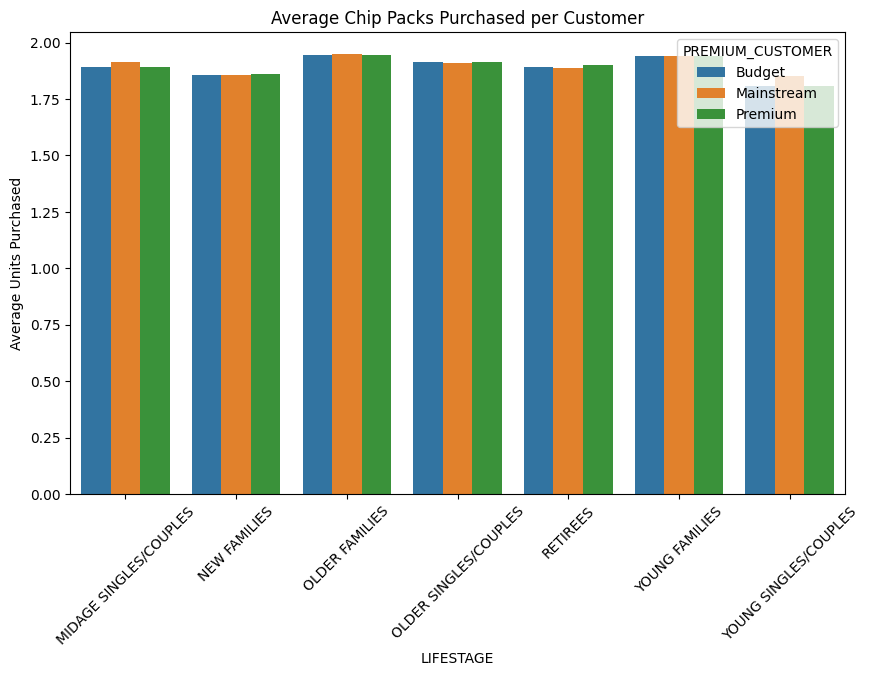

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=units_per_customer,
    x="LIFESTAGE",
    y="PROD_QTY",
    hue="PREMIUM_CUSTOMER"
)

plt.xticks(rotation=45)
plt.title("Average Chip Packs Purchased per Customer")
plt.ylabel("Average Units Purchased")
plt.show()


In [37]:
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]

price_per_segment = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
)["PRICE_PER_UNIT"].mean().reset_index()
